In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grid setup
grid_size = 100
x = np.linspace(0, grid_size, grid_size)
y = np.linspace(0, grid_size, grid_size)
X, Y = np.meshgrid(x, y)

# Initialize the field
field = np.zeros((grid_size, grid_size))

# Node definition
nodes = [
    {'pos': (30, 30), 'coherence': 0.9, 'intention': np.array([1.0, 0.5])},
    {'pos': (70, 30), 'coherence': 0.85, 'intention': np.array([-1.0, 0.8])},
    {'pos': (50, 70), 'coherence': 0.95, 'intention': np.array([0.0, -1.0])},
]

# Ripple emission function
def emit_ripple(x, y, node):
    dx = X - node['pos'][0]
    dy = Y - node['pos'][1]
    distance = np.sqrt(dx**2 + dy**2) + 1e-6  # avoid divide-by-zero
    decay = np.exp(-distance / 10)
    direction = node['intention'][0]*dx + node['intention'][1]*dy
    ripple = node['coherence'] * decay * np.tanh(direction / 20)
    return ripple

# Inject ripples from all nodes
for node in nodes:
    field += emit_ripple(X, Y, node)

# Visualization
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with aggressive aesthetic (deep intentional distortion)
surf = ax.plot_surface(X, Y, field, cmap='plasma', edgecolor='none', linewidth=0, antialiased=True, alpha=0.95)

# Enhance "ripple origin" for each node
for node in nodes:
    ax.scatter(*node['pos'], np.max(field), s=200, c='cyan', marker='*', edgecolor='black', linewidth=1.5)

# Plot aesthetics
ax.set_title("🧠 Ripple Field Emitted by Coherent Nodes with Embedded Intention", fontsize=16, weight='bold')
ax.set_xlabel("X-Axis (Space)", labelpad=15)
ax.set_ylabel("Y-Axis (Space)", labelpad=15)
ax.set_zlabel("Ripple Field Intensity Φ(x, y)", labelpad=15)
ax.view_init(elev=45, azim=225)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'numpy'

In [3]:
# 2D ripple field visualization with directional intention bias (Figure 2 style)

# Create new field for single node ripple
node = {'pos': (50, 50), 'coherence': 1.0, 'intention': np.array([1.0, 0.6])}

# Recalculate ripple field
dx = X - node['pos'][0]
dy = Y - node['pos'][1]
distance = np.sqrt(dx**2 + dy**2) + 1e-6
decay = np.exp(-distance / 10)
directional_bias = node['intention'][0]*dx + node['intention'][1]*dy
ripple_field = node['coherence'] * decay * np.tanh(directional_bias / 20)

# Create quiver vectors to show direction
norm = np.sqrt(dx**2 + dy**2) + 1e-6
Ux = dx / norm * decay
Uy = dy / norm * decay

# Visualization
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, ripple_field, levels=50, cmap='plasma')
plt.colorbar(label='Ripple Intensity Φ(x, y)')
plt.quiver(X[::5, ::5], Y[::5, ::5], Ux[::5, ::5], Uy[::5, ::5], color='white', alpha=0.6)

plt.scatter(*node['pos'], s=150, c='cyan', edgecolor='black', linewidth=1.5, marker='*', label='Ripple Origin')
plt.title("⚡ Directed Ripple Emission from a Single Coherent Node", fontsize=16, weight='bold')
plt.xlabel("X-Axis (Space)")
plt.ylabel("Y-Axis (Space)")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

In [4]:
# Prepare interference field for Figure 3: 2 nodes with opposing ripple directions

# Define two opposing nodes
node_a = {'pos': (35, 50), 'coherence': 1.0, 'intention': np.array([1.0, 0.0])}
node_b = {'pos': (65, 50), 'coherence': 1.0, 'intention': np.array([-1.0, 0.0])}

def ripple_from_node(node):
    dx = X - node['pos'][0]
    dy = Y - node['pos'][1]
    distance = np.sqrt(dx**2 + dy**2) + 1e-6
    decay = np.exp(-distance / 8)
    directional = node['intention'][0]*dx + node['intention'][1]*dy
    return node['coherence'] * decay * np.tanh(directional / 10)

# Calculate interference field
field_a = ripple_from_node(node_a)
field_b = ripple_from_node(node_b)
field_total = field_a + field_b

# Visualization
plt.figure(figsize=(12, 8))
plt.contourf(X, Y, field_total, levels=60, cmap='coolwarm')
plt.colorbar(label="Net Ripple Intensity Φ(x, y)")

# Draw constructive/destructive zones
plt.contour(X, Y, field_total, levels=[-0.5, 0, 0.5], colors=['black'], linewidths=1.0, linestyles=['--', '-', '--'])

# Mark nodes
plt.scatter(*node_a['pos'], s=150, c='lime', edgecolor='black', linewidth=1.5, marker='*', label='Node A')
plt.scatter(*node_b['pos'], s=150, c='magenta', edgecolor='black', linewidth=1.5, marker='*', label='Node B')

plt.title("🧠 Ripple Interference: Constructive vs Destructive Field Regions", fontsize=16, weight='bold')
plt.xlabel("X-Axis (Space)")
plt.ylabel("Y-Axis (Space)")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
grid_size = 100
timesteps = 50
D = 0.1
lambda_decay = 10
coherence_threshold = 0.8

# Initialize field and entropy tracker
field = np.zeros((grid_size, grid_size))
entropy_over_time = []

# Define nodes
nodes = [
    {'position': (30, 30), 'coherence': 0.9, 'entropy_gradient': np.array([1.0, 0.0])},
    {'position': (70, 30), 'coherence': 0.85, 'entropy_gradient': np.array([0.0, 1.0])},
    {'position': (50, 70), 'coherence': 0.95, 'entropy_gradient': np.array([-0.7, -0.7])},
]

# Ripple emission function
def emit_ripples(field, nodes):
    ripple_field = np.zeros_like(field)
    for node in nodes:
        if node['coherence'] >= coherence_threshold:
            x0, y0 = node['position']
            for x in range(grid_size):
                for y in range(grid_size):
                    dx, dy = x - x0, y - y0
                    distance = np.sqrt(dx**2 + dy**2) + 1e-5
                    decay = np.exp(-distance / lambda_decay)
                    ripple_strength = node['coherence'] * np.dot(node['entropy_gradient'], [dx, dy]) / distance
                    ripple_field[x, y] += ripple_strength * decay
    return ripple_field

# Simulation loop
for t in range(timesteps):
    ripple = emit_ripples(field, nodes)
    laplacian = (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) - 4 * field
    )
    field += D * laplacian + ripple
    prob_field = np.exp(field - np.max(field))
    prob_field /= np.sum(prob_field)
    entropy = -np.sum(prob_field * np.log(prob_field + 1e-12))
    entropy_over_time.append(entropy)

# Plot Entropy Drop Rate
plt.figure(figsize=(10, 5))
plt.plot(entropy_over_time, label='Entropy')
plt.title('Entropy Drop Rate Over Time from Ripple Emissions')
plt.xlabel('Timestep')
plt.ylabel('Entropy (nats)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Fix: use custom KL divergence instead of incorrect sklearn import
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

# Simulation parameters
num_agents = 10
timesteps = 50
embedding_dim = 5
noise_level = 0.05

# Define target semantic vector
S_goal = softmax(np.random.randn(embedding_dim))

# Initialize agents with random semantic vectors
agents = [softmax(np.random.randn(embedding_dim)) for _ in range(num_agents)]

# Function to compute KL divergence between agent state and goal
def compute_kl(agent_state, goal_state):
    return np.sum(agent_state * (np.log(agent_state + 1e-12) - np.log(goal_state + 1e-12)))

# Storage
kl_over_time = []

# Simulation loop
for t in range(timesteps):
    kl_sum = 0.0
    for i in range(num_agents):
        # Compute attraction toward the goal (simulated ripple alignment)
        alignment_force = S_goal - agents[i]
        agents[i] += 0.1 * alignment_force + noise_level * np.random.randn(embedding_dim)
        agents[i] = softmax(agents[i])
        kl_sum += compute_kl(agents[i], S_goal)
    kl_over_time.append(kl_sum / num_agents)

# Plot KL Divergence Convergence
plt.figure(figsize=(10, 5))
plt.plot(kl_over_time, label='KL Divergence to Goal')
plt.title('KL Divergence Convergence Over Time from Semantic Ripple Alignment')
plt.xlabel('Timestep')
plt.ylabel('Average KL Divergence')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Simulate HRV data (e.g., average coherence over time during experiment)
np.random.seed(42)
timesteps = 100
baseline_hrv = 0.5 + 0.05 * np.random.randn(timesteps)  # baseline HRV with noise

# Simulated ripple field coherence (peaks during ripple events)
ripple_field_signal = np.zeros(timesteps)
ripple_peaks = [30, 55, 75]
for peak in ripple_peaks:
    ripple_field_signal[peak-3:peak+4] += np.array([0.1, 0.3, 0.5, 0.6, 0.5, 0.3, 0.1])

# Add ripple effect into HRV (simulate resonance)
hrv_signal = baseline_hrv + ripple_field_signal

# Smooth for visual clarity
hrv_signal_smoothed = gaussian_filter1d(hrv_signal, sigma=2)
ripple_field_smoothed = gaussian_filter1d(ripple_field_signal, sigma=2)

# Compute correlation
correlation = np.corrcoef(hrv_signal_smoothed, ripple_field_smoothed)[0, 1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(hrv_signal_smoothed, label='HRV Coherence Signal', linewidth=2)
plt.plot(ripple_field_smoothed, label='Ripple Field Coherence', linewidth=2, linestyle='--')
plt.title(f'HRV–Ripple Alignment (Correlation r = {correlation:.2f})')
plt.xlabel('Timestep')
plt.ylabel('Normalized Signal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
# Install dependencies (if not already installed)
!pip install -q torch pandas matplotlib scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.5 MB/s eta 0:00:00


# 🔁 RippleNet: Intention Prediction via EEG/HRV
Simulated LSTM model using PyTorch.


In [2]:
# Import packages
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [9]:
# Load simulated dataset
url = 'https://raw.githubusercontent.com/tententch/Node-ripple/main/simulated_ripple_dataset.csv'
df = pd.read_csv(url)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()

,Timestamp,EEG_Coherence,HRV_Entropy,Intention_Strength
0,2025-05-01 15:10:56.069055,0.549671,0.746309,0.443627
1,2025-05-01 15:11:01.069067,0.486174,0.795471,0.405251
2,2025-05-01 15:11:06.069069,0.564769,0.630072,0.444609
3,2025-05-01 15:11:11.069071,0.652303,0.728148,0.437122
4,2025-05-01 15:11:16.069073,0.476585,0.667468,0.423446


In [10]:
# Prepare data
features = df[["EEG_Coherence", "HRV_Entropy"]].values
target = df["Intention_Strength"].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Create sequences
time_steps = 10
X_seq, y_seq = [], []
for i in range(time_steps, len(features_scaled)):
    X_seq.append(features_scaled[i-time_steps:i])
    y_seq.append(target[i])
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32).view(-1, 1)

<ipython-input-10-90784550e05c>:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  X_tensor = torch.tensor(X_seq, dtype=torch.float32)


In [11]:
# Train/test split
train_size = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

In [12]:
# Define RippleNet LSTM model
class RippleNet(nn.Module):
    def __init__(self):
        super(RippleNet, self).__init__()
        self.lstm1 = nn.LSTM(input_size=2, hidden_size=64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        return self.fc(out[:, -1, :])

In [13]:
# Train model
model = RippleNet()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(30):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} - Loss: {loss.item():.4f}")

Epoch 0 - Loss: 0.1843
Epoch 5 - Loss: 0.0105
Epoch 10 - Loss: 0.0071
Epoch 15 - Loss: 0.0045
Epoch 20 - Loss: 0.0053
Epoch 25 - Loss: 0.0031


MSE: 0.0016, R²: -0.0472


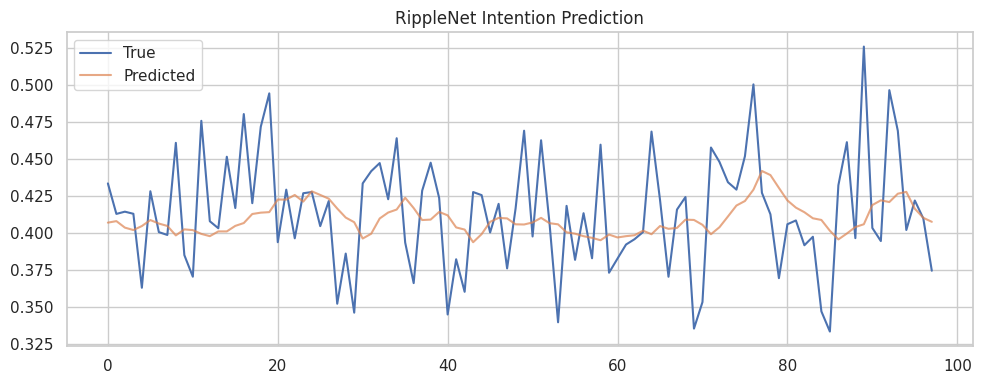

In [14]:
# Evaluate
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy().flatten()
    y_true = y_test.numpy().flatten()
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"MSE: {mse:.4f}, R²: {r2:.4f}")

# Plot
plt.figure(figsize=(10,4))
plt.plot(y_true, label='True')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("RippleNet Intention Prediction")
plt.tight_layout()
plt.show()